# SAMap Cross-Species Analysis

Edit the **Configuration** cell, then run all.

**Kernel:** `samap` (see `environment_samap.yml`)

## 1 · Configuration

In [22]:
import os

# ---------------------------------------------------------------------------
# Species
# ---------------------------------------------------------------------------
# Add or remove entries to change the number of species in the analysis.
# Keys are the short IDs SAMap uses internally (must match the BLAST map filenames).

species_files = {
    "ml": "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/objs/Neural_integrated_merged.h5ad",
    "sm": "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/S_mediterranea/S_mediterranea_Neural_cells.h5ad",
    "sc": "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/S_mansoni/S_mansoni_Neuron_cells.h5ad",
}

# Column in .obs that holds cluster / cell-type labels for each species
cluster_keys = {
    "ml": "final_label_SAMap",
    "sm": "final_label_SAMap",
    "sc": "cell_type",
}

# Human-readable names for plot legends
species_display = {
    "ml": "M. lignano",
    "sm": "S. mediterranea",
    "sc": "S. mansoni",
}

# Colors for each species
species_colors = {
    "ml": "#0072B2",
    "sm": "#D55E00",
    "sc": "#F0E442",
}

# Left-to-right order for Sankey diagrams
sankey_order = ["sm", "ml", "sc"]

# ---------------------------------------------------------------------------
# SAMap
# ---------------------------------------------------------------------------

samap_cell_type = "Neural"

maps_dir      = "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/maps/"          # directory with BLAST / homology maps
run_samap     = False                       # False = load pre-computed object

# ---------------------------------------------------------------------------
# GenePairFinder
# ---------------------------------------------------------------------------
run_genepairfinder     = True                       # False = load pre-computed object

# ---------------------------------------------------------------------------
# Gene-pair expression overlaps
# ---------------------------------------------------------------------------
# TSV with one row per gene pair. Required columns: one per species key
# (e.g. "ml", "sm", "sc") containing gene IDs. Leave a cell blank / NaN
# to exclude that species from a specific pair.
# Optional columns:
#   output_prefix  — filename prefix (defaults to gene IDs joined by "_")
#   label          — human-readable description (used only as a comment)
#
# Example row:
#   label    ml                sm                    sc          output_prefix
#   macpiwi  Mlig455-019997    dd-Smed-v4-15930-0-1              overlap_macpiwi
#
gene_pairs_file = "None"  # set None to skip this section

# ---------------------------------------------------------------------------
# Output directories
# ---------------------------------------------------------------------------
out_dir     = "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/"
figures_dir = os.path.join(out_dir, "figures/", samap_cell_type)
tables_dir  = os.path.join(out_dir, "tables/", samap_cell_type)
objs_dir    = os.path.join(out_dir, "objs/", samap_cell_type)

for d in [figures_dir, tables_dir, objs_dir]:
    os.makedirs(d, exist_ok=True)

# ---------------------------------------------------------------------------
# Analysis options
# ---------------------------------------------------------------------------
describe_data     = True   # print a structural summary of each h5ad
run_umap_sweep    = False   # sweep over UMAP min_dist values (exploratory)
align_thr         = 0.1    # mapping-score threshold (Sankey, CellTypeTriangles)
n_top             = 0      # n_top for get_mapping_scores (0 = keep all)
embedding_key     = "X_umap_samap"

## 2 · Imports

In [2]:
import dill
import warnings
import numpy as np
import pandas as pd
import scanpy as sc

from samap import SAMAP
from samap.analysis import (
    get_mapping_scores,
    GenePairFinder,
    CellTypeTriangles,
    sankey_plot
)

from samap_extension import plotting as splt
from samap_extension import utils

## 3 · (Optional) Inspect input data

In [3]:
if describe_data:
    for sp, path in species_files.items():
        print(f"\n{'='*60}")
        print(f"Species: {species_display.get(sp, sp)}  ({sp})")
        print(f"{'='*60}")
        adata = sc.read_h5ad(path)
        utils.describe_adata(adata)
        del adata


Species: M. lignano  (ml)
Shape: 11,982 cells × 59,995 genes

Cell metadata (obs):
  11,982 cells × 60 columns

  --- orig.ident ---
    11_unsorted_3dph_TCAGCCTGTATTTCGG:  11_unsorted_3dph
    11_unsorted_3dph_AATCGACTCATCGCAA:  11_unsorted_3dph
    11_unsorted_3dph_TGGTTAGTCCGCTGTT:  11_unsorted_3dph
    11_unsorted_3dph_TCATCATAGGTCGTAG:  11_unsorted_3dph
    11_unsorted_3dph_TGGGATTAGAAGGTAG:  11_unsorted_3dph
    11_unsorted_3dph_TTCCGGTCACTTGACA:  11_unsorted_3dph
    11_unsorted_3dph_TGTTTGTAGTTGCTCA:  11_unsorted_3dph
    11_unsorted_3dph_GTGAGCCCAACGGCTC:  11_unsorted_3dph
    11_unsorted_3dph_TCAGTTTCAGTCCGTG:  11_unsorted_3dph
    11_unsorted_3dph_ACGTAGTCAATCTCTT:  11_unsorted_3dph

  --- nCount_RNA ---
    11_unsorted_3dph_TCAGCCTGTATTTCGG:  3470.0
    11_unsorted_3dph_AATCGACTCATCGCAA:  3330.0
    11_unsorted_3dph_TGGTTAGTCCGCTGTT:  3341.0
    11_unsorted_3dph_TCATCATAGGTCGTAG:  3275.0
    11_unsorted_3dph_TGGGATTAGAAGGTAG:  3131.0
    11_unsorted_3dph_TTCCGGTCACTTGACA: 

## 4 · Run or load SAMap

In [4]:
samap_obj_path = os.path.join(objs_dir, "SAMap_cross_species_annotation.obj")

if run_samap:
    sm = SAMAP(species_files, f_maps=maps_dir)
    sm.run()
    with open(samap_obj_path, "wb") as fh:
        dill.dump(sm, fh)
    print(f"SAMap object saved to: {samap_obj_path}")
else:
    with open(samap_obj_path, "rb") as fh:
        sm = dill.load(fh)
    print(f"SAMap object loaded from: {samap_obj_path}")

SAMap object loaded from: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/objs/Neural/SAMap_cross_species_annotation.obj


## 5 · Mapping scores

In [5]:
D, MappingTable = get_mapping_scores(sm, cluster_keys, n_top=n_top)

# Save mapping table
table_path = os.path.join(tables_dir, "mapping_scores.tsv")
pd.DataFrame(MappingTable).to_csv(table_path, sep="\t")
print(f"Mapping table saved to: {table_path}")

Mapping table saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Neural/mapping_scores.tsv


## 6 · Joint UMAP — coloured by species

In [6]:
file_path = "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/S_mediterranea/S_mediterranea_Neural_cells.h5ad"
adata = sc.read_h5ad(file_path)

adata.obs["Cluster.ID"].value_counts()

Cluster.ID
8     2049
9     1573
18     738
20     734
21     696
23     667
32     229
33     223
34     219
36     205
Name: count, dtype: int64

In [7]:
adata.obs["Major.cluster.description"].value_counts()

Major.cluster.description
Neural    7333
Name: count, dtype: int64

In [8]:
adata.obs["Subcluster.ID"].value_counts()

Subcluster.ID
3;                       849
10;                      570
7;                       345
8;                       336
5;  Ciliated: 2          312
                        ... 
45; Non-ciliated: 4        1
41;  Ciliated: 1           1
47; Non-ciliated: 0        1
42;  Ciliated: 7           1
60; Non-ciliated: 16       1
Name: count, Length: 140, dtype: int64

In [9]:
pd.crosstab(
    adata.obs["Cluster.ID"],
    adata.obs["Subcluster.ID"]
)

Subcluster.ID,0;,1;,2;,3;,4;,5; Ciliated: 2,5; Ciliated: 4,5; Ciliated: 5,5; Ciliated: 6,5; Ciliated: 16,...,52; Non-ciliated: 13,53; Ciliated: 18,54; Non-ciliated: 20,55; Non-ciliated: 17,56; Non-ciliated: 26,57; Ciliated: 19,58; Non-ciliated: 29,59;,60; Non-ciliated: 16,60; Non-ciliated: 32
Cluster.ID,,,,,,,,,,,,,,,,,,,,,
8,7,0,7,829,3,0,0,0,0,0,...,0,0,1,0,24,0,27,24,1,24
9,0,0,0,7,14,308,1,0,1,2,...,0,0,41,0,0,37,0,0,0,0
18,2,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
20,0,0,0,0,0,0,0,1,0,0,...,0,54,0,0,0,0,0,0,0,0
21,3,0,0,1,0,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,0
23,1,0,0,12,7,4,0,0,0,0,...,3,0,0,0,0,0,0,2,0,1
32,0,0,0,0,0,0,0,0,0,0,...,0,0,0,41,0,0,0,0,0,0
33,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34,1,1,0,0,205,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


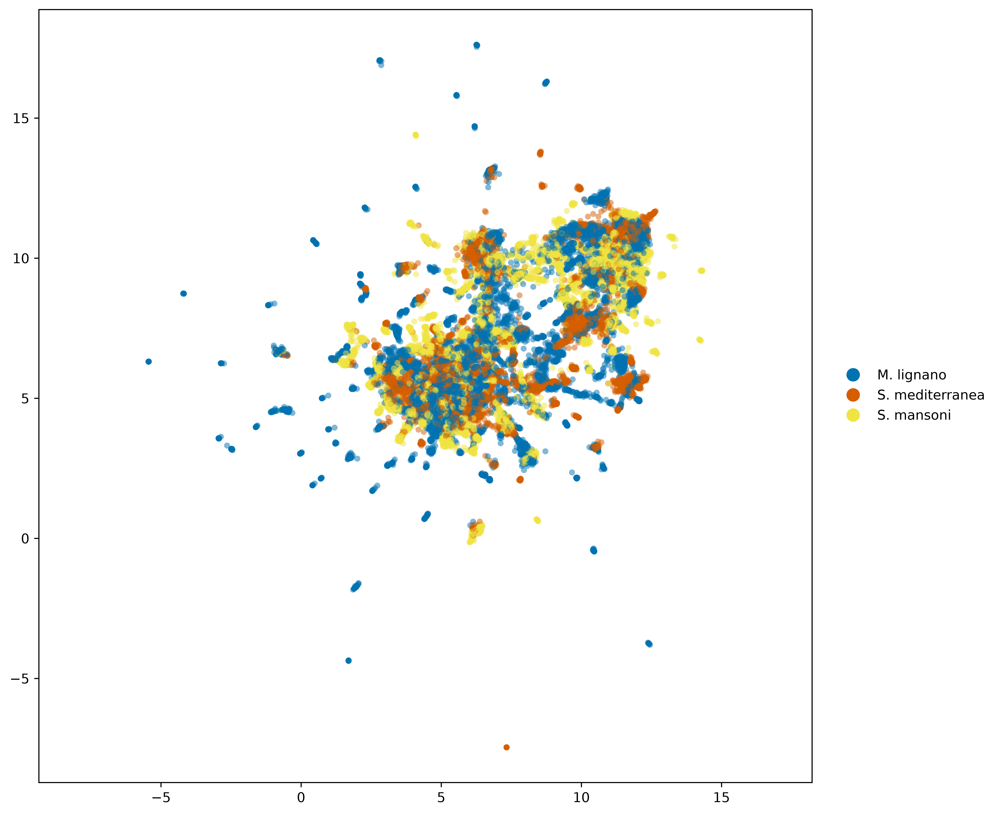

In [10]:
fig, ax = splt.square_scatter(
    sm,
    COLORS=species_colors,
    species_labels=species_display,
    figsize=(8, 8),
    dpi=600,
    s=20,
    alpha=0.5,
)
fig.savefig(
    os.path.join(figures_dir, "umap_by_species.pdf"),
    dpi=600,
    bbox_inches="tight",
)

## 7 · Joint UMAP — coloured by cell type per species

Produces one figure per species, highlighting that species' cluster
labels against all other cells in gray.

Saved: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/figures/Neural/umap_labels_ml.pdf
Saved: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/figures/Neural/umap_labels_sm.pdf
Saved: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/figures/Neural/umap_labels_sc.pdf


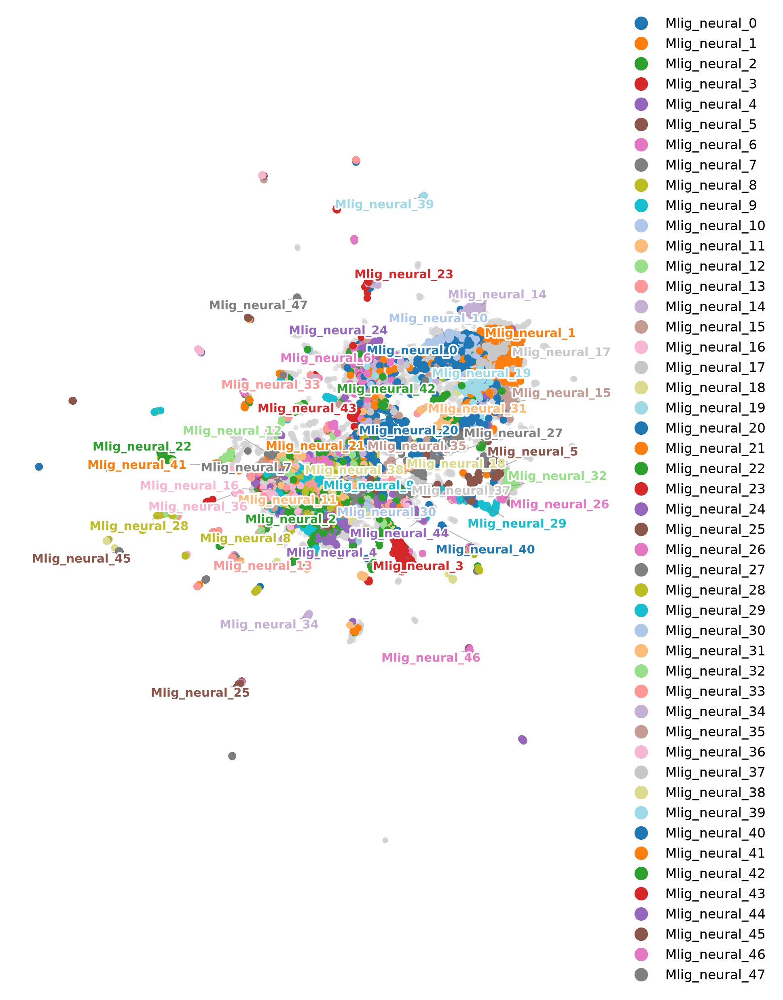

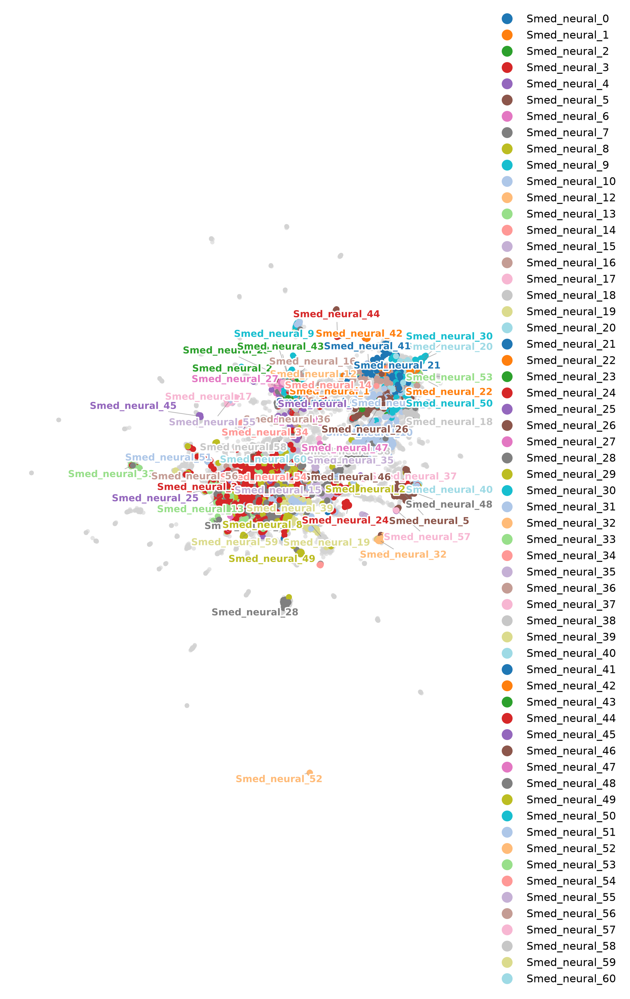

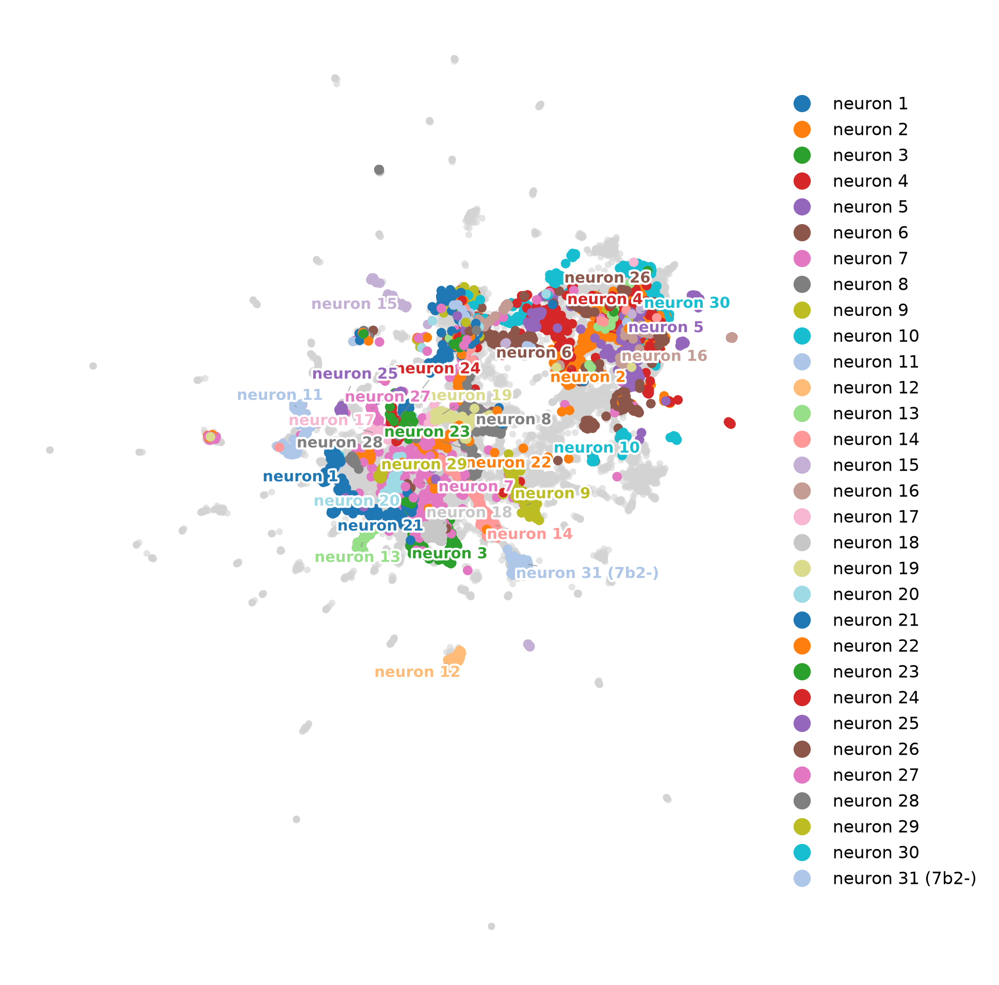

In [11]:
for sp, col in cluster_keys.items():
    out_path = os.path.join(figures_dir, f"umap_labels_{sp}.pdf")
    fig, ax = splt.plot_joint_umap(
        sm,
        species=sp,
        label_col=col,
        embedding_key=embedding_key,
        figsize=(8, 8),
        dpi=300,
        s_other=10,     # background cells
        s_target=20,    # target species cells
        save_to=out_path,
        label_clusters=True,
        label_fontsize=7,
        label_outline=True,
    )
    print(f"Saved: {out_path}")

## 8 · Sankey diagram

Uses `sankey_plot_3` for 3 species (two-panel layout keeping the
middle column aligned) and falls back to a single-panel Sankey for
2 species.

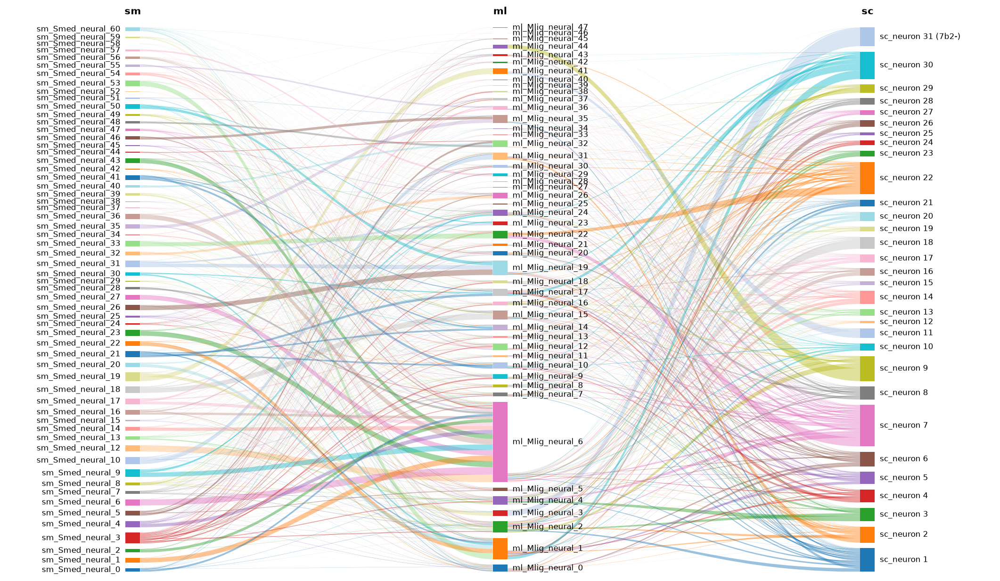

(<Figure size 2700x1500 with 1 Axes>, <Axes: >)

In [12]:
n_species = len(species_files)
two_panel = n_species == 3

sankey = splt.sankey_plot_3(
    MappingTable,
    species_order=["sm", "ml", "sc"],
    align_thr=0,
    figsize=(18, 10),
    save_to=os.path.join(figures_dir, "sankey_thr_0.pdf"),
)
sankey

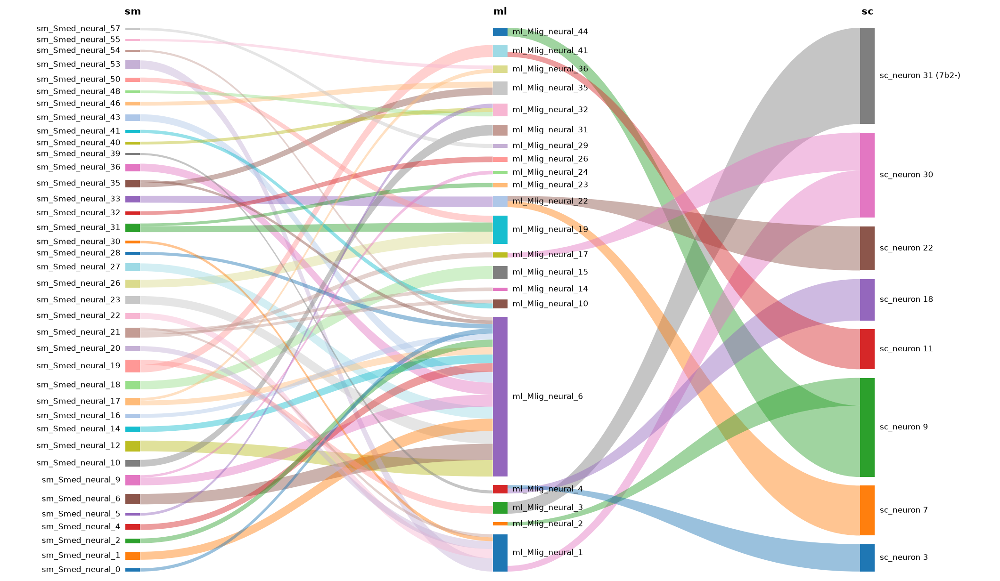

(<Figure size 2700x1500 with 1 Axes>, <Axes: >)

In [13]:
n_species = len(species_files)
two_panel = n_species == 3

sankey = splt.sankey_plot_3(
    MappingTable,
    species_order=["sm", "ml", "sc"],
    align_thr=0.15,
    figsize=(18, 10),
    save_to=os.path.join(figures_dir, "sankey_thr_0_15.pdf"),
)
sankey

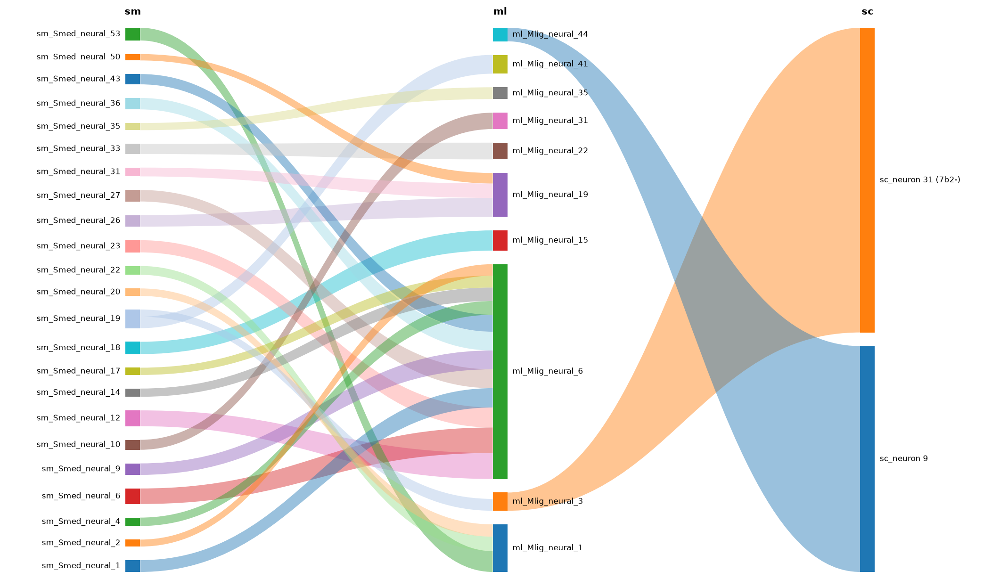

(<Figure size 2700x1500 with 1 Axes>, <Axes: >)

In [14]:
n_species = len(species_files)
two_panel = n_species == 3

sankey = splt.sankey_plot_3(
    MappingTable,
    species_order=["sm", "ml", "sc"],
    align_thr=0.3,
    figsize=(18, 10),
    save_to=os.path.join(figures_dir, "sankey_thr_0_3.pdf"),
)
sankey

## 10 · Gene pair finder

In [15]:
gpf_path = os.path.join(objs_dir, "gene_pair_finder_thr_0.obj")
gene_pairs_path = os.path.join(objs_dir, "gene_pairs_thr_0.obj")

if run_genepairfinder:
    gpf = GenePairFinder(sm, keys=cluster_keys)
    gene_pairs = gpf.find_all(align_thr=0)
    with open(gpf_path, "wb") as fh:
        dill.dump(gpf, fh)

    with open(gene_pairs_path, "wb") as fh:
        dill.dump(gene_pairs, fh)
  
    pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0.tsv")
    gene_pairs.to_csv(pairs_path, sep="\t")
    print(f"Gene pairs saved to: {pairs_path}")
    gene_pairs.head(20)

else:
    with open(gpf_path, "rb") as fh:
        gpf = dill.load(fh)
    with open(gene_pairs_path, "rb") as fh:
        gene_pairs = dill.load(fh)
    
    print(f"GenePairFinder object loaded from: {gpf_path}")

    pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0.tsv")
    gene_pairs.to_csv(pairs_path, sep="\t")
    print(f"Gene pairs saved to: {pairs_path}")
    gene_pairs.head(20)

GenePairFinder object loaded from: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/objs/Neural/gene_pair_finder_thr_0.obj
Gene pairs saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Neural/gene_pairs_thr_0.tsv


In [23]:
gpf_path = os.path.join(objs_dir, "gene_pair_finder_thr_0_15.obj")
gene_pairs_path = os.path.join(objs_dir, "gene_pairs_thr_0_15.obj")

if run_genepairfinder:
    gpf = GenePairFinder(sm, keys=cluster_keys)
    gene_pairs = gpf.find_all(align_thr=0.15)
    with open(gpf_path, "wb") as fh:
        dill.dump(gpf, fh)

    with open(gene_pairs_path, "wb") as fh:
        dill.dump(gene_pairs, fh)
  
    pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0_15.tsv")
    gene_pairs.to_csv(pairs_path, sep="\t")
    print(f"Gene pairs saved to: {pairs_path}")
    gene_pairs.head(20)

else:
    with open(gpf_path, "rb") as fh:
        gpf = dill.load(fh)
    with open(gene_pairs_path, "rb") as fh:
        gene_pairs = dill.load(fh)
    
    print(f"GenePairFinder object loaded from: {gpf_path}")

    pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0_15.tsv")
    gene_pairs.to_csv(pairs_path, sep="\t")
    print(f"Gene pairs saved to: {pairs_path}")
    gene_pairs.head(20)

INFO: Finding cluster-specific markers in ml:final_label_SAMap.
INFO: Finding cluster-specific markers in sm:final_label_SAMap.
INFO: Finding cluster-specific markers in sc:cell_type.
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1 to sc;neuron 30
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1 to sm;Smed_neural_20
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1 to sm;Smed_neural_21
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1 to sm;Smed_neural_22
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1 to sm;Smed_neural_30
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1 to sm;Smed_neural_53
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_10 to sm;Smed_neural_21
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_10 to sm;Smed_neural_41
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_14 to sm;Smed_neural_21
INFO: Calculating gene pairs for the mapping: ml;Mlig_neural_1

KeyboardInterrupt: 

In [ ]:
gpf_path = os.path.join(objs_dir, "gene_pair_finder_thr_0_3.obj")
gene_pairs_path = os.path.join(objs_dir, "gene_pairs_thr_0_3.obj")

if run_genepairfinder:
    gpf = GenePairFinder(sm, keys=cluster_keys)
    gene_pairs = gpf.find_all(align_thr=0.3)
    with open(gpf_path, "wb") as fh:
        dill.dump(gpf, fh)

    with open(gene_pairs_path, "wb") as fh:
        dill.dump(gene_pairs, fh)
  
    pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0_3.tsv")
    gene_pairs.to_csv(pairs_path, sep="\t")
    print(f"Gene pairs saved to: {pairs_path}")
    gene_pairs.head(20)

else:
    with open(gpf_path, "rb") as fh:
        gpf = dill.load(fh)
    with open(gene_pairs_path, "rb") as fh:
        gene_pairs = dill.load(fh)
    
    print(f"GenePairFinder object loaded from: {gpf_path}")

    pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0_3.tsv")
    gene_pairs.to_csv(pairs_path, sep="\t")
    print(f"Gene pairs saved to: {pairs_path}")
    gene_pairs.head(20)

## 11 · Expression overlap plots

Reads gene pairs from `gene_pairs_file` (TSV defined in Configuration).
Columns must include one entry per species key; blank / NaN cells exclude
that species from the pair. An `output_prefix` column is optional.

In [18]:
#if gene_pairs_file is not None:
#    gp_df = pd.read_csv(gene_pairs_file, sep="\t", dtype=str).fillna("")
#
#    for _, row in gp_df.iterrows():
#        # Build genes dict, skipping species with no gene assigned
#        genes = {
#            sp: row[sp]
#            for sp in species_files
#            if sp in row.index and row[sp] != ""
#        }
#        if len(genes) < 2:
#            print(f"Skipping row (fewer than 2 species with genes): {dict(row)}")
#            continue

        # Build output prefix: use column if present, else join gene IDs
#        if "output_prefix" in row.index and row["output_prefix"] != "":
#            prefix = os.path.join(figures_dir, row["output_prefix"])
#        else:
#            prefix = os.path.join(figures_dir, "overlap_" + "_".join(genes.values()))

        # Restrict colors to species actually in this pair
#        pair_colors = {sp: species_colors[sp] for sp in genes}

#        samap_extension.save_expression_overlap_plot(
#            sm=sm,
#            genes=genes,
#            colors=pair_colors,
#            species_labels=species_display,
#            overlap_color="#FFEE8C",
#            figsize=(5, 5),
#            dpi=600,
#            point_size=20,
#            save_pdf=False,
#            output_prefix=prefix,
#            show=True,
#        )
#        print(f"Saved: {prefix}.png")
#else:
#    print("gene_pairs_file is None — skipping expression overlap plots.")

## 12 · Cell type triangles

In [19]:
triangles = CellTypeTriangles(sm, cluster_keys, align_thr=0)

tri_path = os.path.join(tables_dir, "cell_type_triangles_thr_0.tsv")
triangles.to_csv(tri_path, sep="\t")
print(f"Cell type triangles saved to: {tri_path}")
triangles.head(20)

Cell type triangles saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Neural/cell_type_triangles_thr_0.tsv


,ml,sm,sc
0,ml_Mlig_neural_0,sm_Smed_neural_0,sc_neuron 1
1,ml_Mlig_neural_0,sm_Smed_neural_10,sc_neuron 1
2,ml_Mlig_neural_0,sm_Smed_neural_13,sc_neuron 1
3,ml_Mlig_neural_0,sm_Smed_neural_14,sc_neuron 1
4,ml_Mlig_neural_0,sm_Smed_neural_15,sc_neuron 1
5,ml_Mlig_neural_0,sm_Smed_neural_16,sc_neuron 1
6,ml_Mlig_neural_0,sm_Smed_neural_17,sc_neuron 1
7,ml_Mlig_neural_0,sm_Smed_neural_18,sc_neuron 1
8,ml_Mlig_neural_0,sm_Smed_neural_19,sc_neuron 1
9,ml_Mlig_neural_0,sm_Smed_neural_2,sc_neuron 1


In [20]:
triangles = CellTypeTriangles(sm, cluster_keys, align_thr=0.15)

tri_path = os.path.join(tables_dir, "cell_type_triangles_thr_0_15.tsv")
triangles.to_csv(tri_path, sep="\t")
print(f"Cell type triangles saved to: {tri_path}")
triangles.head(20)

Cell type triangles saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Neural/cell_type_triangles_thr_0_15.tsv


,ml,sm,sc
0,ml_Mlig_neural_1,sm_Smed_neural_22,sc_neuron 30
1,ml_Mlig_neural_22,sm_Smed_neural_33,sc_neuron 22
2,ml_Mlig_neural_22,sm_Smed_neural_33,sc_neuron 7


In [21]:
triangles = CellTypeTriangles(sm, cluster_keys, align_thr=0.3)

tri_path = os.path.join(tables_dir, "cell_type_triangles_thr_0_3.tsv")
triangles.to_csv(tri_path, sep="\t")
print(f"Cell type triangles saved to: {tri_path}")
triangles.head(20)

ValueError: need at least one array to concatenate